# GEARS — Notebook 1: GMM Descriptive Analysis

**Objective:** Thorough descriptive analysis of the pre-fitted GMMs in the GEARS registry.

No raw data is required — the GMMs are fitted on the French national dataset and shipped with the package.

**Sections**
1. Load GMM from the registry
2. Access the underlying sklearn objects
3. Component weights and means
4. Descriptive statistics per stratum
5. Session distributions by location type
6. Seasonal patterns (arrival hour by season)
7. Day-of-week patterns
8. Département coverage map
9. BIC component count summary

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os; os.makedirs("outputs", exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.mixture import GaussianMixture

import gears
from gears import NativeGMMRegistry, get_gmm, load_sessions
from gears.data.schemas import _season

## 1. Load GMM from the registry

Use `NativeGMMRegistry` to list and load the unified French bundle.  
The single `'french'` bundle covers all location types, stratified by  
`location_type × département × day_of_week × season`.

In [2]:
registry = NativeGMMRegistry()
print(registry)
print()
print(registry.list().to_string(index=False))

NativeGMMRegistry(1/1 GMMs available, dir=C:\Users\yvenn\EDF\GEARS\gears\data\gmm)

gmm_id                                                                                                                                               description  available  is_sample                                      stratify_by
french French national EV dataset — single GMM stratified by location_type × département × season × day_of_week (8 008 contexts, full dataset, is_sample=False).       True      False [location_type, department, day_of_week, season]


In [3]:
# Single unified bundle — all location types in one EVSessionGMM object
gmm = registry.load("french")

n_ctx  = len(gmm.models_)
flag   = "⚠  sample data" if gmm.is_sample_ else "✓  full data"
locs   = sorted(set(c[0] for c in gmm.list_contexts()))
depts  = sorted(set(c[1] for c in gmm.list_contexts()))

print(f"Loaded GMM: {n_ctx} contexts | stratify_by={gmm.stratify_by} | {flag}")
print(f"Location types : {locs}")
print(f"Departments    : {depts}")
if gmm.metadata_:
    print(f"Metadata       : {gmm.metadata_}")

Loaded GMM: 8008 contexts | stratify_by=['location_type', 'department', 'day_of_week', 'season'] | ✓  full data
Location types : ['heavy', 'home', 'public', 'work']
Departments    : ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '21', '22', '23', '24', '25', '26', '27', '28', '29', '2a', '2b', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '8', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '9', '90', '91', '92', '93', '94', '95', '971', '972', '974', '978']
Metadata       : {'gmm_id': 'french', 'n_training_sessions': 8357487, 'stratify_by': ['location_type', 'department', 'day_of_week', 'season'], 'year': 2025}


In [4]:
# First 12 context keys — each is (location_type, department, day_of_week, season)
print("French GMM — fitted context keys (first 12):")
for ctx in list(gmm.list_contexts())[:12]:
    print(f"  {ctx}")
print(f"  ... ({len(gmm.list_contexts())} total)")

French GMM — fitted context keys (first 12):
  ('heavy', '1', 0, 'autumn')
  ('heavy', '1', 0, 'spring')
  ('heavy', '1', 0, 'summer')
  ('heavy', '1', 0, 'winter')
  ('heavy', '1', 1, 'autumn')
  ('heavy', '1', 1, 'spring')
  ('heavy', '1', 1, 'summer')
  ('heavy', '1', 1, 'winter')
  ('heavy', '1', 2, 'autumn')
  ('heavy', '1', 2, 'spring')
  ('heavy', '1', 2, 'summer')
  ('heavy', '1', 2, 'winter')
  ... (8008 total)


## 2. Access the underlying sklearn GaussianMixture objects

Two access patterns are available:
- `gmm.get_sklearn_gmm(context=...)` on the EVSessionGMM wrapper
- `gears.get_gmm(loc_type, dept, saison, dow)` for the registry retrieval API

Feature space: `[arrival_hour, log1p(duration_h), log1p(energy_kWh)]`

In [5]:
# Pattern 1 — direct context dict on the loaded GMM
ctx_key  = gmm.list_contexts()[0]
ctx_dict = dict(zip(gmm.stratify_by, ctx_key))
print(f"Context: {ctx_dict}")

sk_gmm: GaussianMixture = gmm.get_sklearn_gmm(context=ctx_dict)
print(f"\nsklearn type  : {type(sk_gmm).__name__}")
print(f"n_components  : {sk_gmm.n_components}")
print(f"covariance    : {sk_gmm.covariance_type}")
print(f"Weights       : {sk_gmm.weights_.round(3)}")

# Back-transform means to human-readable units
means_bt = sk_gmm.means_.copy()
means_bt[:, 1] = np.expm1(means_bt[:, 1])   # log1p(duration) → hours
means_bt[:, 2] = np.expm1(means_bt[:, 2])   # log1p(energy)   → kWh
print("\nComponent means (back-transformed):")
print(pd.DataFrame(means_bt, columns=["Arrival hour", "Duration (h)", "Energy (kWh)"]).round(2).to_string())

Context: {'location_type': 'heavy', 'department': '1', 'day_of_week': 0, 'season': 'autumn'}

sklearn type  : GaussianMixture
n_components  : 6
covariance    : full
Weights       : [0.029 0.412 0.324 0.029 0.088 0.118]

Component means (back-transformed):
   Arrival hour  Duration (h)  Energy (kWh)
0         11.00          0.68          2.30
1         15.24         15.52         34.06
2         12.64          1.80         33.71
3          5.13          2.76         53.69
4          7.82          1.24         14.63
5         11.73         16.95         45.97


In [6]:
# Pattern 2 — registry retrieval API: gears.get_gmm(loc_type, dept, saison, dow)
gmm_retrieved = get_gmm("work", "92", "winter", 0)
print("Retrieved via get_gmm('work', '92', 'winter', 0):")
print(repr(gmm_retrieved))

# Sample 20 sessions for Hauts-de-Seine / work / winter / Monday
ctx_paris = {"location_type": "work", "department": "92", "season": "winter", "day_of_week": 0}
sessions_sample = gmm_retrieved.sample(20, context=ctx_paris, seed=42)
print("\nSampled 20 sessions (Hauts-de-Seine, work, winter, Monday):")
print(sessions_sample[["arrival_hour", "duration", "energy"]].round(2).head(5))

Retrieved via get_gmm('work', '92', 'winter', 0):
EVSessionGMM(n_contexts=8008, stratify_by=['location_type', 'department', 'day_of_week', 'season'], n_components='auto', max_samples=5000, fitted=True)

Sampled 20 sessions (Hauts-de-Seine, work, winter, Monday):
   arrival_hour  duration  energy
0          6.68     11.41   21.30
1          6.84      9.08    9.75
2          7.91      9.14   14.91
3          5.81      8.51   17.10
4          5.50     10.47   14.43


## 3. Component weights and means

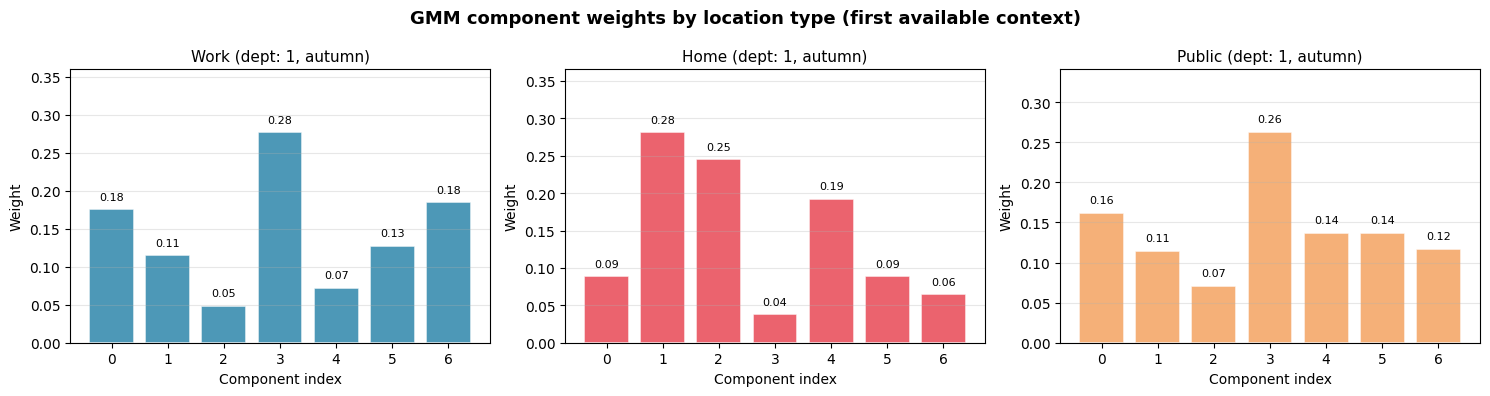

In [7]:
# ── Component weight bar chart — one subplot per location type ──────────────
COLORS = {"work": "#2E86AB", "home": "#E84855", "public": "#F4A261", "heavy": "#3BB273"}
loc_types = ["work", "home", "public"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, loc in zip(axes, loc_types):
    ctx_key  = next(c for c in gmm.list_contexts() if c[0] == loc)
    ctx_dict = dict(zip(gmm.stratify_by, ctx_key))
    sk       = gmm.get_sklearn_gmm(context=ctx_dict)
    k = sk.n_components
    bars = ax.bar(range(k), sk.weights_, color=COLORS[loc], alpha=0.85,
                  edgecolor="white", linewidth=1.2)
    for bar, w in zip(bars, sk.weights_):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{w:.2f}", ha="center", va="bottom", fontsize=8)
    ax.set_title(f"{loc.capitalize()} (dept: {ctx_key[1]}, {ctx_key[3]})", fontsize=11)
    ax.set_xlabel("Component index"); ax.set_ylabel("Weight")
    ax.set_xticks(range(k))
    ax.set_ylim(0, max(sk.weights_) * 1.3)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("GMM component weights by location type (first available context)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/01_component_weights.png", dpi=150, bbox_inches="tight")
plt.show()

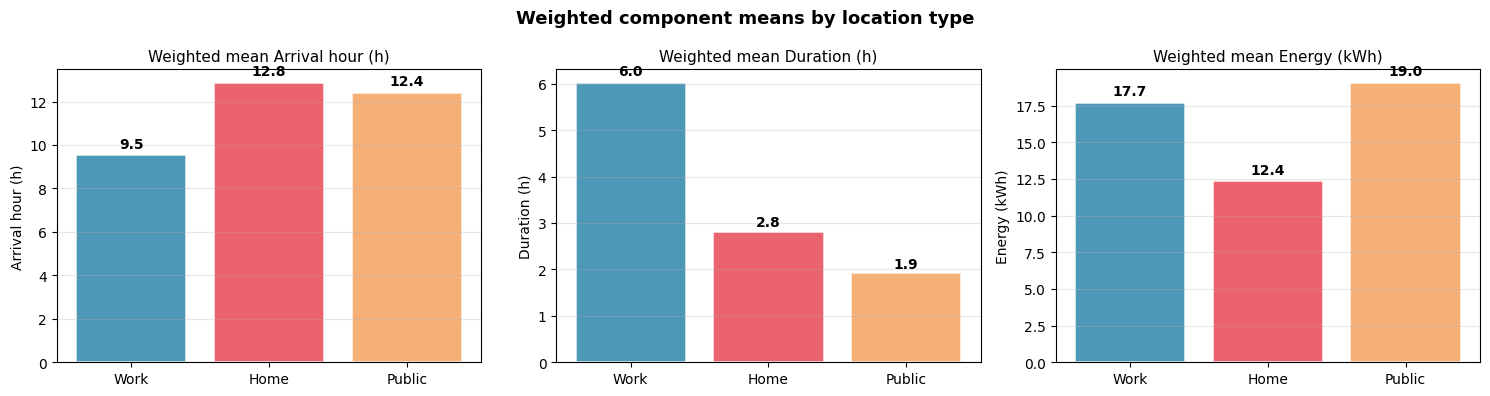

In [8]:
# ── Aggregate component means across all contexts (weighted by mixture weights) ─
def aggregate_means(gmm_obj, loc_filter=None):
    rows = []
    for ctx, sk in gmm_obj.models_.items():
        ctx_d = dict(zip(gmm_obj.stratify_by, ctx))
        if loc_filter and ctx_d.get("location_type") != loc_filter:
            continue
        for k in range(sk.n_components):
            rows.append({
                "location_type": ctx_d.get("location_type", "?"),
                "component": k,
                "weight": sk.weights_[k],
                "arrival_hour": sk.means_[k, 0],
                "duration_h": np.expm1(sk.means_[k, 1]),
                "energy_kwh": np.expm1(sk.means_[k, 2]),
            })
    return pd.DataFrame(rows)

all_means = aggregate_means(gmm)

# ── Weighted mean per metric per location type ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [("arrival_hour", "Arrival hour (h)"),
           ("duration_h",   "Duration (h)"),
           ("energy_kwh",   "Energy (kWh)")]

for ax, (metric, label) in zip(axes, metrics):
    vals, labels, colors = [], [], []
    for loc in ["work", "home", "public"]:
        sub = all_means[all_means["location_type"] == loc]
        if sub.empty:
            continue
        w_mean = np.average(sub[metric], weights=sub["weight"])
        vals.append(w_mean); labels.append(loc.capitalize())
        colors.append(COLORS[loc])
    bars = ax.bar(labels, vals, color=colors, alpha=0.85, edgecolor="white", linewidth=1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f"{v:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_ylabel(label)
    ax.set_title(f"Weighted mean {label}", fontsize=11)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Weighted component means by location type", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/01_location_means.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Descriptive statistics per stratum

Summary statistics derived from GMM component means (weighted by mixture weights).  
Each stratum is a `(location_type, department, day_of_week, season)` context.

In [9]:
# ── Build full summary: one row per context ──────────────────────────────────
summary_rows = []
for ctx, sk in gmm.models_.items():
    ctx_d = dict(zip(gmm.stratify_by, ctx))
    n_samp = gmm.context_counts_.get(ctx, 0)
    # Weighted means (back-transformed)
    w_arrival  = float(np.average(sk.means_[:, 0], weights=sk.weights_))
    w_duration = float(np.average(np.expm1(sk.means_[:, 1]), weights=sk.weights_))
    w_energy   = float(np.average(np.expm1(sk.means_[:, 2]), weights=sk.weights_))
    summary_rows.append({
        **ctx_d,
        "n_components": sk.n_components,
        "n_samples": n_samp,
        "mean_arrival_h": round(w_arrival, 2),
        "mean_duration_h": round(w_duration, 2),
        "mean_energy_kwh": round(w_energy, 2),
    })

ctx_df = pd.DataFrame(summary_rows)

# ── Per-stratum summary: aggregate by location_type × season ────────────────
agg = (
    ctx_df
    .groupby(["location_type", "season"])
    .agg(
        n_contexts=("n_components", "count"),
        total_samples=("n_samples", "sum"),
        mean_arrival_h=("mean_arrival_h", "mean"),
        mean_duration_h=("mean_duration_h", "mean"),
        mean_energy_kwh=("mean_energy_kwh", "mean"),
    )
    .round(2)
    .reset_index()
)
season_order = ["winter", "spring", "summer", "autumn"]
agg["season"] = pd.Categorical(agg["season"], categories=season_order, ordered=True)
agg = agg.sort_values(["location_type", "season"])

print("── Summary statistics per stratum (location_type × season) ─────────────────")
print(agg.to_string(index=False))

── Summary statistics per stratum (location_type × season) ─────────────────
location_type season  n_contexts  total_samples  mean_arrival_h  mean_duration_h  mean_energy_kwh
        heavy winter         292          20998           12.77             9.47            85.09
        heavy spring         293          20944           12.62            11.27            80.37
        heavy summer         297          21272           12.15             9.86            87.16
        heavy autumn         305          26451           12.11            10.20            88.85
         home winter         389         191136           12.62             2.83            12.06
         home spring         387         189044           12.18             2.77            12.32
         home summer         381         169062           12.20             2.74            12.52
         home autumn         388         193373           14.34             2.87            12.59
       public winter         680        1

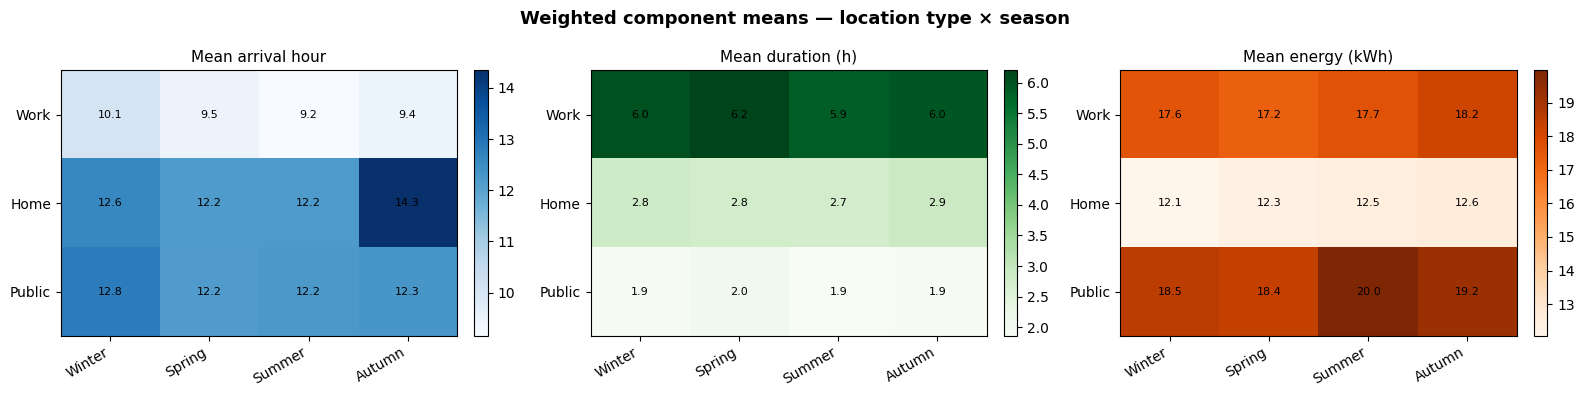

In [10]:
# ── Heatmap: weighted-mean metrics by location_type × season ────────────────
SEASON_ORDER  = ["winter", "spring", "summer", "autumn"]
LOC_TYPES_VIS = ["work", "home", "public"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
metrics_h = [
    ("mean_arrival_h",  "Mean arrival hour",   "Blues"),
    ("mean_duration_h", "Mean duration (h)",   "Greens"),
    ("mean_energy_kwh", "Mean energy (kWh)",   "Oranges"),
]

for ax, (col, title, cmap) in zip(axes, metrics_h):
    mat = np.full((len(LOC_TYPES_VIS), len(SEASON_ORDER)), np.nan)
    for i, loc in enumerate(LOC_TYPES_VIS):
        for j, sea in enumerate(SEASON_ORDER):
            sub = agg[(agg["location_type"] == loc) & (agg["season"] == sea)]
            if not sub.empty:
                mat[i, j] = sub[col].values[0]
    im = ax.imshow(mat, aspect="auto", cmap=cmap, interpolation="nearest")
    ax.set_xticks(range(len(SEASON_ORDER)))
    ax.set_xticklabels([s.capitalize() for s in SEASON_ORDER], rotation=30, ha="right")
    ax.set_yticks(range(len(LOC_TYPES_VIS)))
    ax.set_yticklabels([l.capitalize() for l in LOC_TYPES_VIS])
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for i in range(len(LOC_TYPES_VIS)):
        for j in range(len(SEASON_ORDER)):
            if not np.isnan(mat[i, j]):
                ax.text(j, i, f"{mat[i, j]:.1f}", ha="center", va="center",
                        fontsize=8, color="black")

fig.suptitle("Weighted component means — location type × season", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/01_stratum_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Session distributions by location type

Simulate 2 000 sessions per location type and plot marginal distributions.

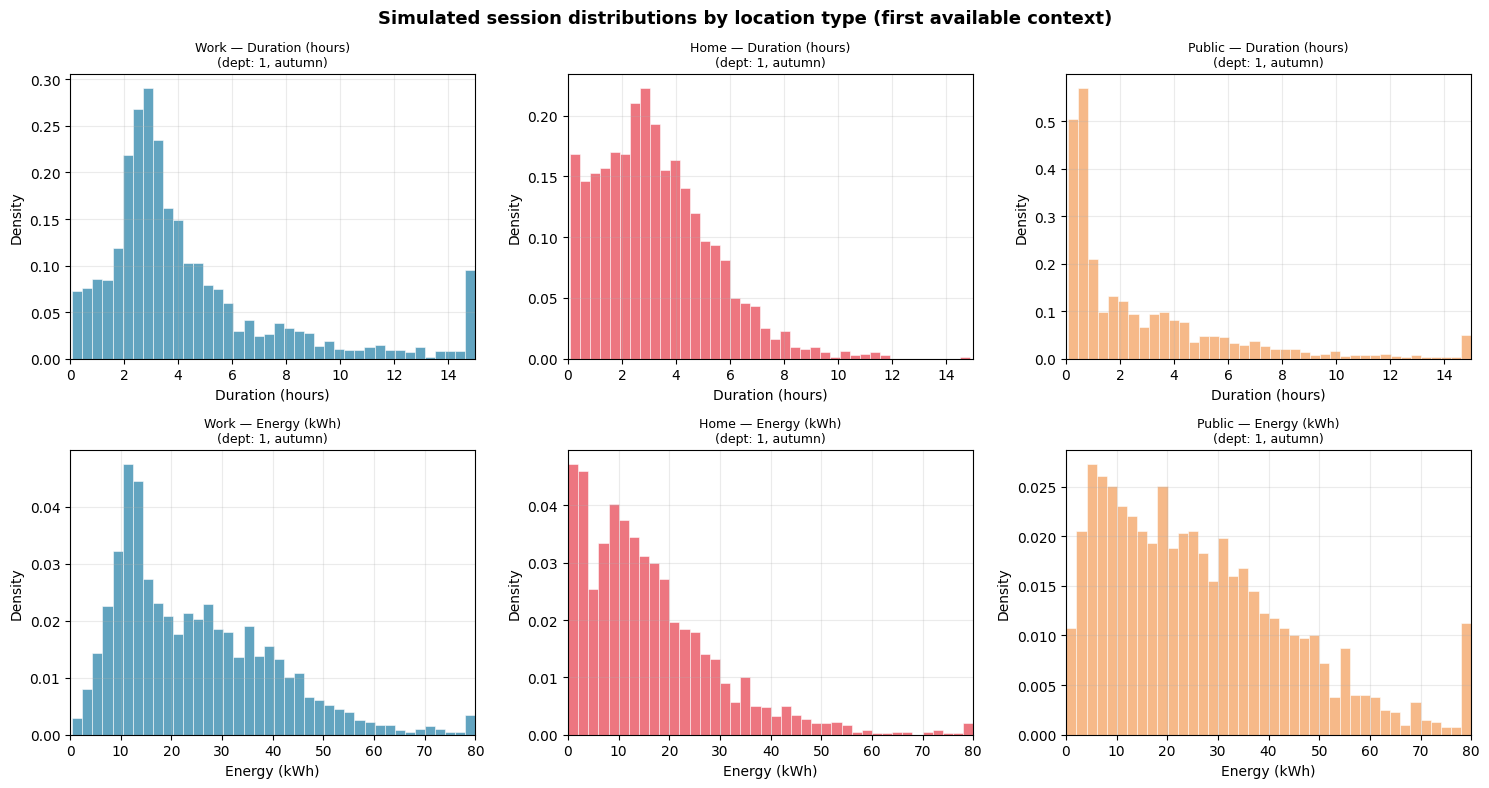

In [11]:
# ── Simulated marginal distributions — duration & energy by location type ───
def first_ctx(loc_type):
    """Return context dict for the first available context of this location type."""
    ctx_key = next((c for c in gmm.list_contexts() if c[0] == loc_type), None)
    return dict(zip(gmm.stratify_by, ctx_key)) if ctx_key else None

loc_configs = [
    ("Work",   "work",   first_ctx("work"),   COLORS["work"]),
    ("Home",   "home",   first_ctx("home"),   COLORS["home"]),
    ("Public", "public", first_ctx("public"), COLORS["public"]),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, (label, loc, ctx, color) in enumerate(loc_configs):
    samp = gmm.sample(2000, context=ctx, seed=42)
    for row, (feat, xlabel, xlim) in enumerate([
        ("duration", "Duration (hours)", (0, 15)),
        ("energy",   "Energy (kWh)",     (0, 80)),
    ]):
        ax = axes[row, col]
        ax.hist(samp[feat].clip(0, xlim[1]), bins=40, density=True,
                color=color, alpha=0.75, edgecolor="white", linewidth=0.5)
        ax.set_xlabel(xlabel); ax.set_ylabel("Density")
        ax.set_xlim(0, xlim[1])
        ax.set_title(f"{label} — {xlabel}\n(dept: {ctx['department']}, {ctx['season']})", fontsize=9)
        ax.grid(True, alpha=0.25)

fig.suptitle("Simulated session distributions by location type (first available context)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/01_marginals_by_location.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Seasonal patterns — arrival hour by season

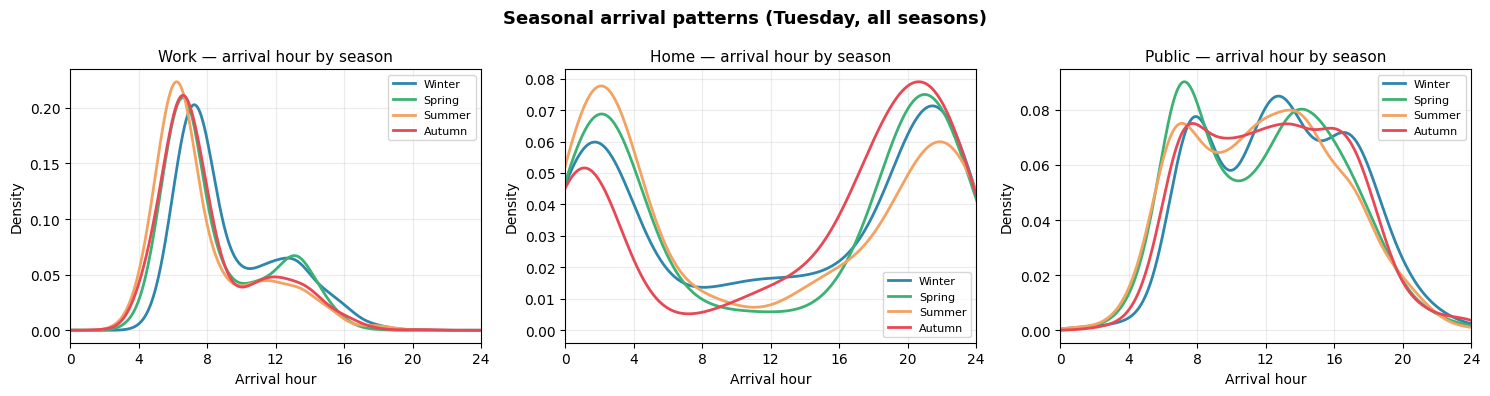

In [12]:
# ── Arrival-hour KDE by season × location type ──────────────────────────────
SEASONS = ["winter", "spring", "summer", "autumn"]
SEASON_COLORS = {
    "winter": "#2E86AB", "spring": "#3BB273",
    "summer": "#F4A261", "autumn": "#E84855",
}

def find_ctx(loc_type, season, dow_pref=1):
    """Return a context dict for a given (loc_type, season)."""
    # Prefer a weekday context (dow=1) for a fair seasonal comparison
    for ctx in gmm.list_contexts():
        ctx_d = dict(zip(gmm.stratify_by, ctx))
        if ctx_d.get("location_type") == loc_type and ctx_d.get("season") == season:
            if ctx_d.get("day_of_week") == dow_pref:
                return ctx_d
    # Fallback: any context with this loc_type + season
    for ctx in gmm.list_contexts():
        ctx_d = dict(zip(gmm.stratify_by, ctx))
        if ctx_d.get("location_type") == loc_type and ctx_d.get("season") == season:
            return ctx_d
    return None

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, loc in zip(axes, ["work", "home", "public"]):
    for season in SEASONS:
        ctx = find_ctx(loc, season)
        if ctx is None:
            continue
        samp = gmm.sample(1500, context=ctx, seed=0)
        samp["arrival_hour"].plot.kde(
            ax=ax, label=season.capitalize(),
            color=SEASON_COLORS[season], linewidth=2,
        )
    ax.set_xlim(0, 24)
    ax.set_xticks(range(0, 25, 4))
    ax.set_xlabel("Arrival hour"); ax.set_ylabel("Density")
    ax.set_title(f"{loc.capitalize()} — arrival hour by season", fontsize=11)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.25)

fig.suptitle("Seasonal arrival patterns (Tuesday, all seasons)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/01_arrival_by_season.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Day-of-week patterns

Weighted average arrival hour and energy by day-of-week, computed from component means.

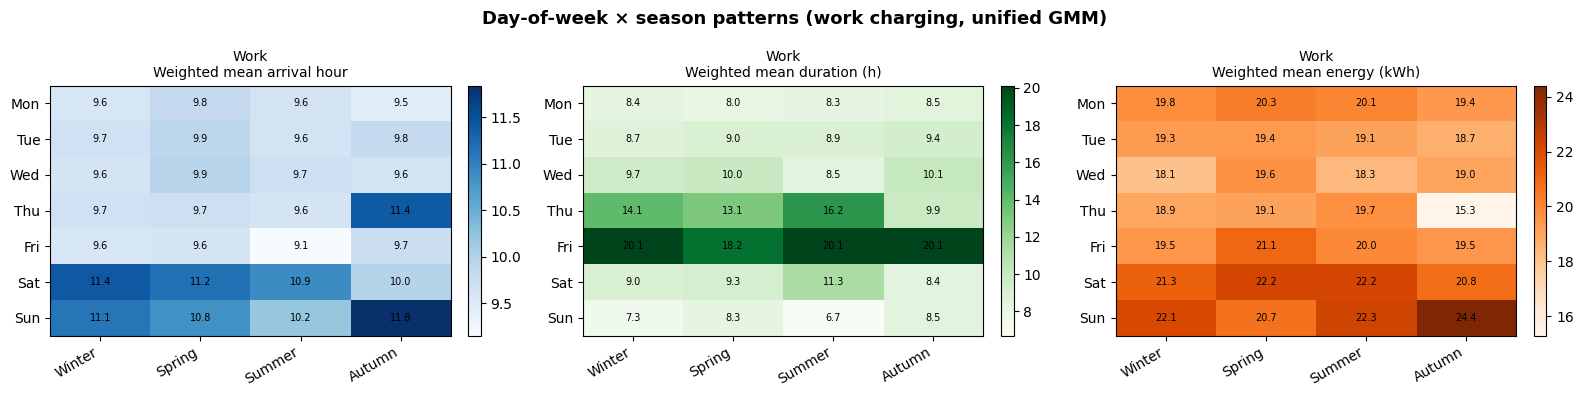

In [13]:
# ── Day-of-week × season heatmap (Work contexts) ────────────────────────────
DOW_LABELS   = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
SEASON_ORDER = ["winter", "spring", "summer", "autumn"]

def dow_season_matrix(gmm_obj, metric="arrival_hour", loc_filter=None):
    """Build (7 × 4) matrix of weighted component means."""
    mat = np.full((7, 4), np.nan)
    for ctx, sk in gmm_obj.models_.items():
        ctx_d = dict(zip(gmm_obj.stratify_by, ctx))
        if loc_filter and ctx_d.get("location_type") != loc_filter:
            continue
        dow = ctx_d.get("day_of_week")
        sea = ctx_d.get("season")
        if dow is None or sea not in SEASON_ORDER:
            continue
        si = SEASON_ORDER.index(sea)
        if metric == "arrival_hour":
            vals = sk.means_[:, 0]
        elif metric == "energy_kwh":
            vals = np.expm1(sk.means_[:, 2])
        else:
            vals = np.expm1(sk.means_[:, 1])
        # Accumulate (average across multiple departments per cell)
        cell_val = np.average(vals, weights=sk.weights_)
        if np.isnan(mat[dow, si]):
            mat[dow, si] = cell_val
        else:
            mat[dow, si] = (mat[dow, si] + cell_val) / 2
    return mat

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
heatmap_metrics = [
    ("arrival_hour", "Weighted mean arrival hour", "Blues"),
    ("duration_h",   "Weighted mean duration (h)", "Greens"),
    ("energy_kwh",   "Weighted mean energy (kWh)", "Oranges"),
]
for ax, (metric, title, cmap) in zip(axes, heatmap_metrics):
    mat = dow_season_matrix(gmm, metric, loc_filter="work")
    im = ax.imshow(mat, aspect="auto", cmap=cmap, interpolation="nearest")
    ax.set_xticks(range(4))
    ax.set_xticklabels([s.capitalize() for s in SEASON_ORDER], rotation=30, ha="right")
    ax.set_yticks(range(7)); ax.set_yticklabels(DOW_LABELS)
    ax.set_title(f"Work\n{title}", fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for i in range(7):
        for j in range(4):
            if not np.isnan(mat[i, j]):
                ax.text(j, i, f"{mat[i, j]:.1f}", ha="center", va="center",
                        fontsize=7, color="black")

fig.suptitle("Day-of-week × season patterns (work charging, unified GMM)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/01_dow_season_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

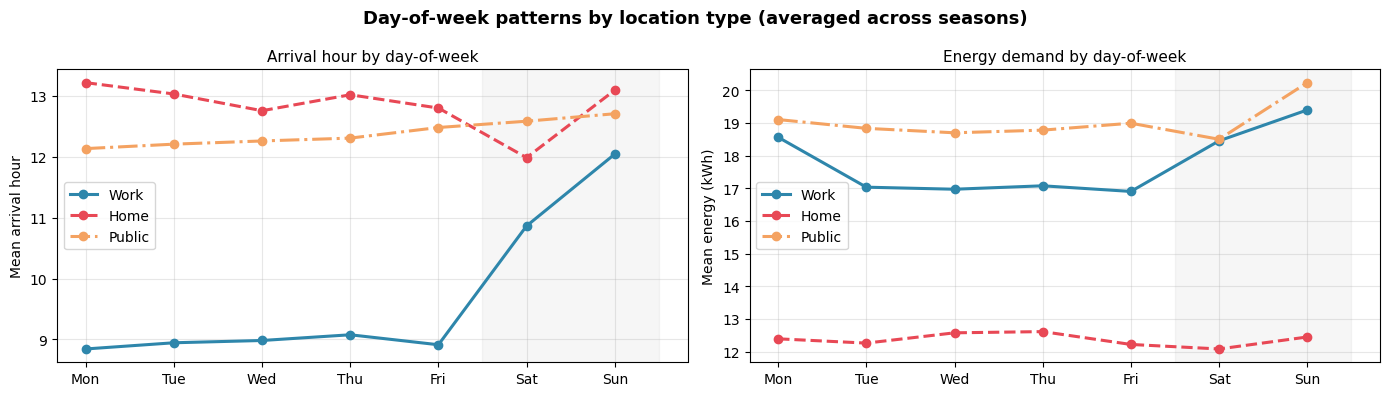

In [14]:
# ── Day-of-week line plots: mean arrival hour & energy (all 3 location types) ─
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
loc_styles = [
    ("work",   "#2E86AB", "-"),
    ("home",   "#E84855", "--"),
    ("public", "#F4A261", "-."),
]

for metric_idx, (ax, ylabel, title) in enumerate(zip(axes,
    ["Mean arrival hour", "Mean energy (kWh)"],
    ["Arrival hour by day-of-week", "Energy demand by day-of-week"]
)):
    for loc, color, ls in loc_styles:
        dow_vals = []
        for d in range(7):
            vals_all, weights_all = [], []
            for ctx, sk in gmm.models_.items():
                ctx_d = dict(zip(gmm.stratify_by, ctx))
                if ctx_d.get("location_type") != loc:
                    continue
                if ctx_d.get("day_of_week") != d:
                    continue
                if metric_idx == 0:
                    vals_all.extend(sk.means_[:, 0].tolist())
                else:
                    vals_all.extend(np.expm1(sk.means_[:, 2]).tolist())
                weights_all.extend(sk.weights_.tolist())
            dow_vals.append(np.average(vals_all, weights=weights_all) if vals_all else np.nan)
        ax.plot(range(7), dow_vals, color=color, linestyle=ls, linewidth=2.2,
                marker="o", markersize=6, label=loc.capitalize())
    ax.set_xticks(range(7)); ax.set_xticklabels(DOW_LABELS)
    ax.set_ylabel(ylabel); ax.set_title(title, fontsize=11)
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.axvspan(4.5, 6.5, alpha=0.07, color="gray")

fig.suptitle("Day-of-week patterns by location type (averaged across seasons)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/01_dow_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Département coverage map

Training sample count by département — bubble size indicates data density.  
Département centroids are approximate (INSEE 2024).

In [15]:
# ── Département coverage table ────────────────────────────────────────────────
def dept_coverage(gmm_obj):
    """Aggregate context stats by department."""
    rows = []
    for ctx, sk in gmm_obj.models_.items():
        ctx_d = dict(zip(gmm_obj.stratify_by, ctx))
        rows.append({
            "department": ctx_d.get("department", "all"),
            "n_components": sk.n_components,
            "n_samples": gmm_obj.context_counts_.get(ctx, 0),
        })
    df_cov = pd.DataFrame(rows)
    return (
        df_cov.groupby("department")
        .agg(n_contexts=("n_components", "count"),
             mean_k=("n_components", "mean"),
             total_samples=("n_samples", "sum"))
        .reset_index()
        .sort_values("total_samples", ascending=False)
    )

cov_global = dept_coverage(gmm)
print(f"Departments covered: {len(cov_global)}")
print(cov_global.to_string(index=False))

Departments covered: 100
department  n_contexts    mean_k  total_samples
        92         112  9.196429         384837
        78         108 10.101852         299806
        69         108 11.416667         293985
        94         109  9.238532         258878
        31         110  8.290909         244771
        59         104  9.278846         241174
        13         108 10.490741         229087
        33         108  9.453704         209163
        91          91  9.384615         207403
        93         110  9.181818         203119
        75         108  9.592593         202102
         6         110 10.000000         193318
        95         112  9.133929         191033
        44         104  9.067308         174059
        38         112  7.348214         170690
        67         110  9.500000         168548
        77         112  8.660714         166269
        57          89  9.662921         153576
        62         109  7.339450         151533
        76     

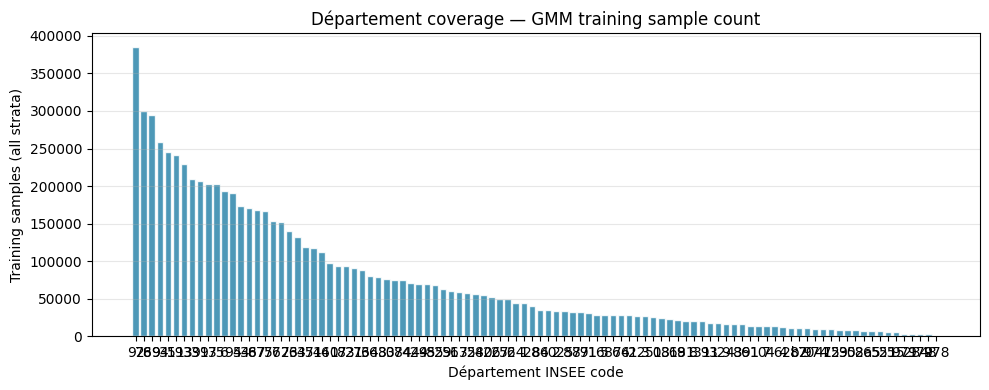

In [16]:
# ── Bar chart: departments by training sample count ────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(
    cov_global["department"].astype(str),
    cov_global["total_samples"],
    color="#2E86AB", alpha=0.85, edgecolor="white",
)
ax.set_xlabel("Département INSEE code")
ax.set_ylabel("Training samples (all strata)")
ax.set_title("Département coverage — GMM training sample count", fontsize=12)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.savefig("outputs/01_dept_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

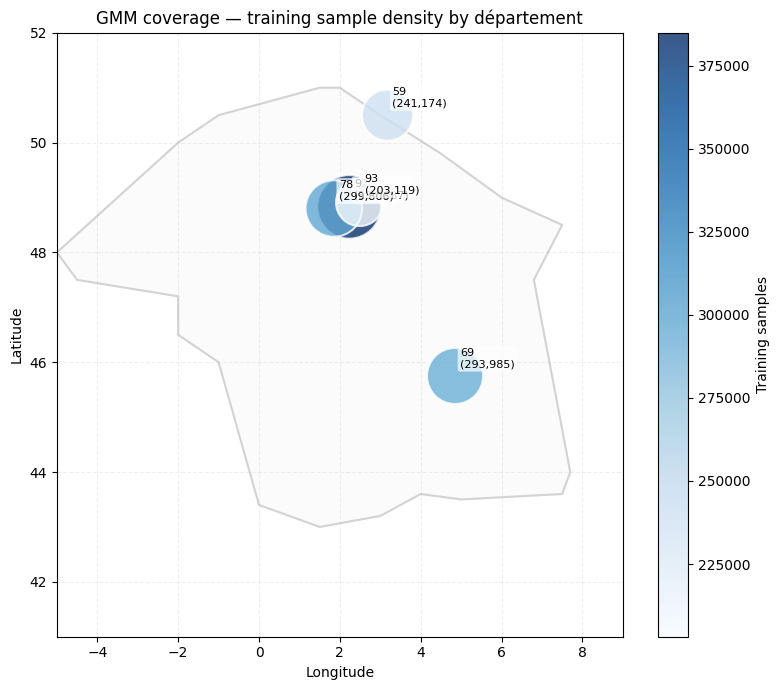

In [17]:
# ── Geographic scatter map — département centroids ──────────────────────────
# Approximate centroids (lat, lon) for covered French départements
DEPT_CENTROIDS = {
    "59": (50.50, 3.18),   # Nord
    "69": (45.75, 4.85),   # Rhône
    "78": (48.80, 1.85),   # Yvelines
    "92": (48.83, 2.23),   # Hauts-de-Seine
    "93": (48.91, 2.49),   # Seine-Saint-Denis
}

# Merge with coverage data
cov_geo = cov_global.copy()
cov_geo["lat"] = cov_geo["department"].map(lambda d: DEPT_CENTROIDS.get(d, (np.nan, np.nan))[0])
cov_geo["lon"] = cov_geo["department"].map(lambda d: DEPT_CENTROIDS.get(d, (np.nan, np.nan))[1])
cov_geo = cov_geo.dropna(subset=["lat", "lon"])

fig, ax = plt.subplots(figsize=(8, 7))

# France rough bounding box
ax.set_xlim(-5, 9); ax.set_ylim(41, 52)

# Draw approximate France outline
france_outline = [
    (-5, 48), (-4.5, 47.5), (-2, 47.2), (-2, 46.5), (-1, 46),
    (0, 43.4), (1.5, 43), (3, 43.2), (4, 43.6), (5, 43.5),
    (7.5, 43.6), (7.7, 44), (6.8, 47.5), (7.5, 48.5),
    (6, 49), (4.5, 49.8), (3, 50.5), (2, 51), (1.5, 51),
    (-1, 50.5), (-2, 50), (-5, 48),
]
xs, ys = zip(*france_outline)
ax.plot(xs, ys, color="lightgray", linewidth=1.5, zorder=1)
ax.fill(xs, ys, color="#f8f8f8", alpha=0.5, zorder=0)

# Scatter bubbles — size ∝ training samples
max_s = cov_geo["total_samples"].max()
sc = ax.scatter(
    cov_geo["lon"], cov_geo["lat"],
    s=cov_geo["total_samples"] / max_s * 2000 + 100,
    c=cov_geo["total_samples"],
    cmap="Blues", alpha=0.8, edgecolors="white", linewidth=1.5, zorder=5,
)

# Labels
for _, row in cov_geo.iterrows():
    ax.text(row["lon"] + 0.12, row["lat"] + 0.12,
            f"{row['department']}\n({row['total_samples']:,})",
            fontsize=8, ha="left", va="bottom", zorder=6,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))

plt.colorbar(sc, ax=ax, label="Training samples")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("GMM coverage — training sample density by département", fontsize=12)
ax.grid(True, alpha=0.2, linestyle="--")
fig.tight_layout()
plt.savefig("outputs/01_coverage_map.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. BIC component count summary

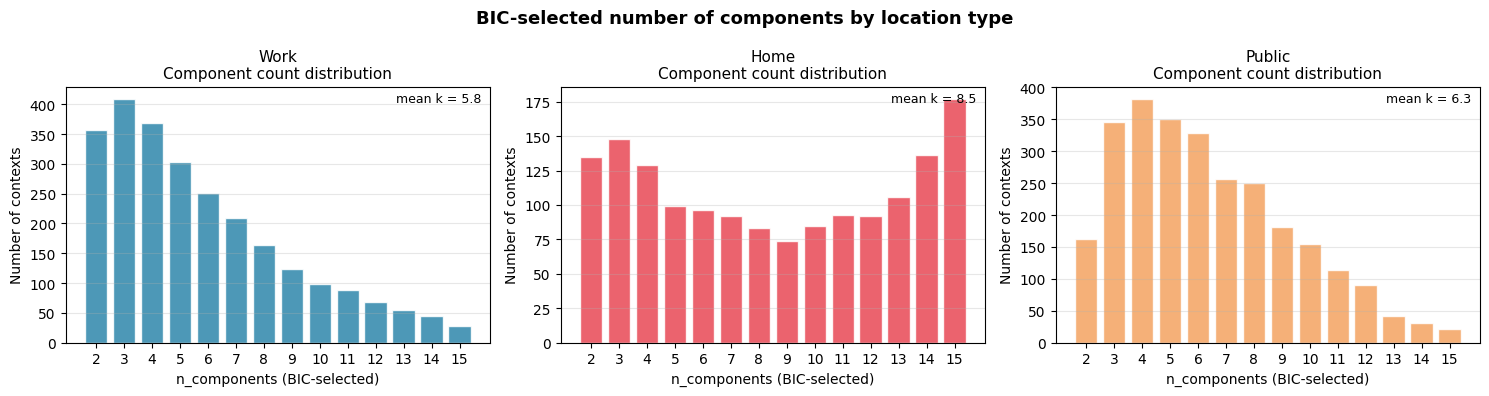

In [18]:
# ── BIC-selected number of components per context ────────────────────────────
bic_all = gmm.bic_summary()
# Add location_type column from context tuple
bic_all["location_type"] = bic_all["context"].apply(lambda c: c[0])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (loc, color) in zip(axes, [
    ("work",   COLORS["work"]),
    ("home",   COLORS["home"]),
    ("public", COLORS["public"]),
]):
    bdf = bic_all[bic_all["location_type"] == loc]
    vc  = bdf["n_components"].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color=color, alpha=0.85, edgecolor="white")
    mean_k = bdf["n_components"].mean()
    ax.set_xlabel("n_components (BIC-selected)")
    ax.set_ylabel("Number of contexts")
    ax.set_title(f"{loc.capitalize()}\nComponent count distribution", fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.text(0.98, 0.98, f"mean k = {mean_k:.1f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9)

fig.suptitle("BIC-selected number of components by location type", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/01_bic_components.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Item | Detail |
|---|---|
| Registry bundle | `french` (single unified object) |
| Stratification | `location_type × department × day_of_week × season` |
| Location types | `work`, `home`, `public`, `heavy` |
| Retrieval API | `gears.get_gmm(loc_type, dept, saison, dow)` → `EVSessionGMM` wrapper |
| sklearn access | `gmm.get_sklearn_gmm(context=...)` → `GaussianMixture` |
| Feature space | `[arrival_hour, log1p(duration_h), log1p(energy_kWh)]` |
| Components (BIC) | Typically 3–7 per context |

**Key observations:**
- Work charging peaks sharply at 08–09h on weekdays, diffuse on weekends
- Home charging peaks in the evening (18–21h), stable across seasons
- Public charging shows a bimodal pattern (lunch + evening)
- Energy demand is highest on weekdays for work, flatter for public
- Season has a modest effect on arrival time but a stronger effect on duration and energy
